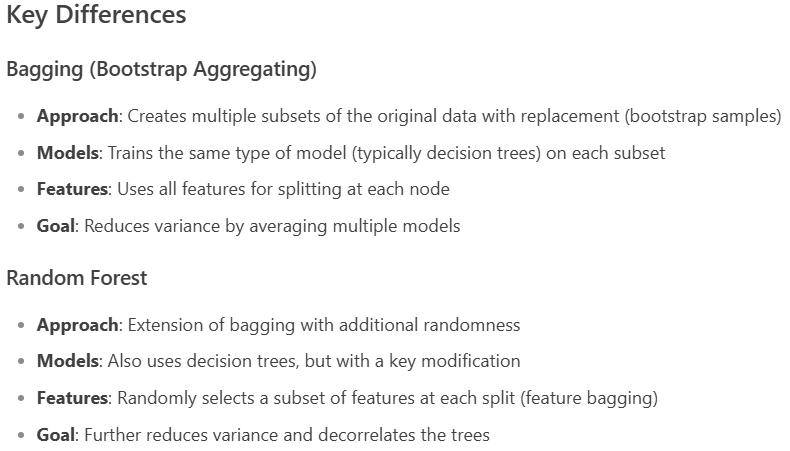

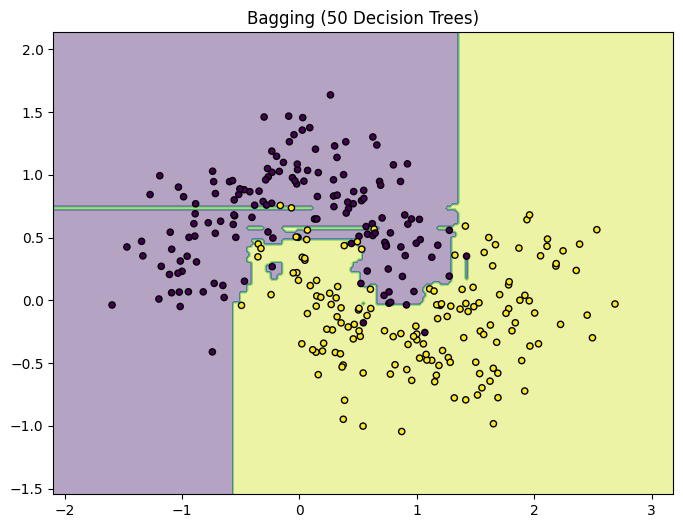

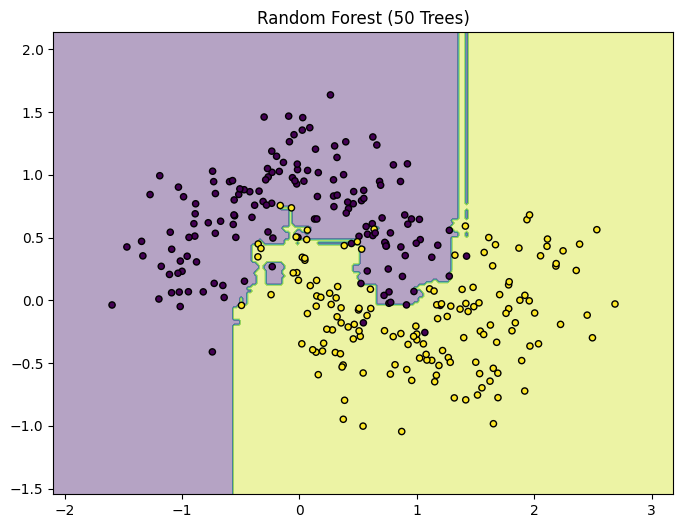

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# Create sample data
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# Bagging classifier
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    max_samples=0.8,
    bootstrap=True,
    random_state=42
)

# Random Forest classifier
random_forest = RandomForestClassifier(
    n_estimators=50,
    max_samples=0.8,
    bootstrap=True,
    max_features='sqrt',  # Key difference - feature subsampling
    random_state=42
)

# Train both models
bagging.fit(X, y)
random_forest.fit(X, y)

# Visualization function
def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    plt.title(title)
    plt.show()

# Plot results
plot_decision_boundary(bagging, X, y, "Bagging (50 Decision Trees)")
plot_decision_boundary(random_forest, X, y, "Random Forest (50 Trees)")

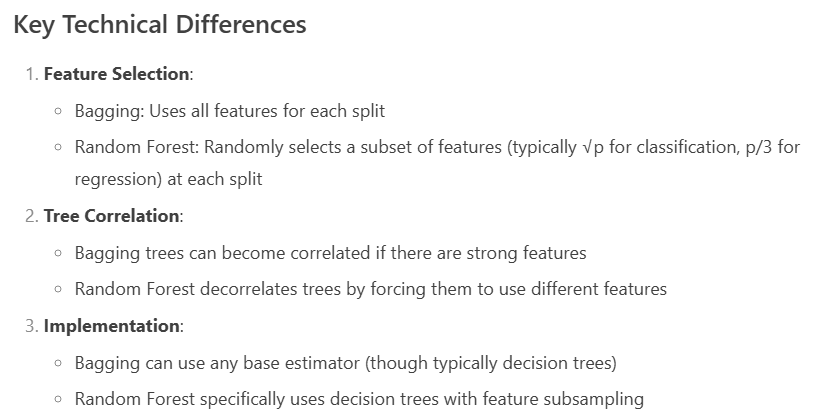

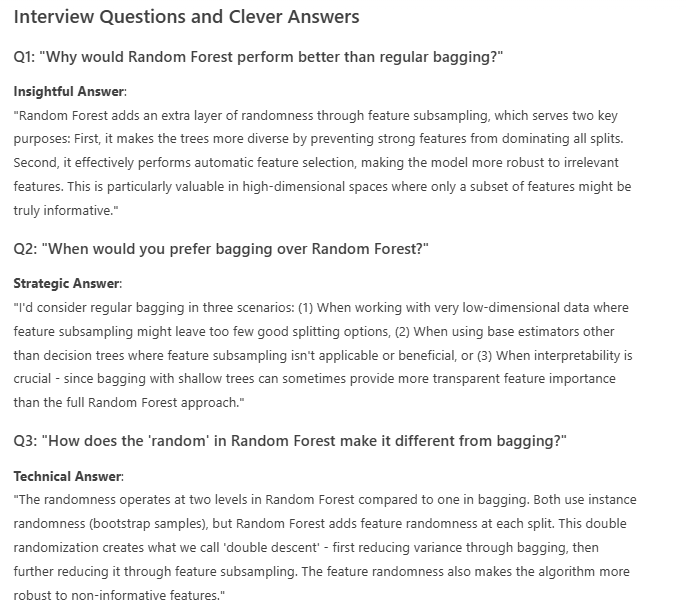

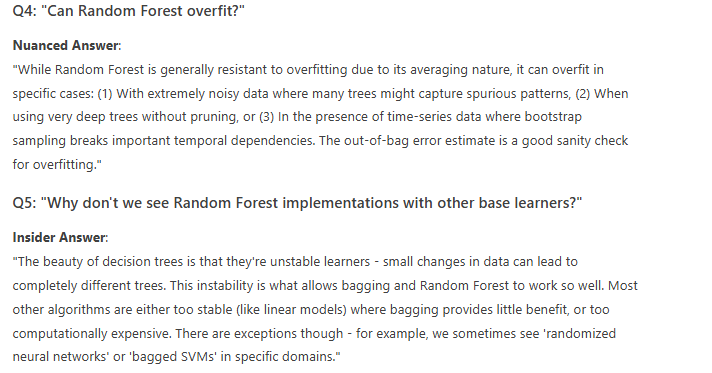

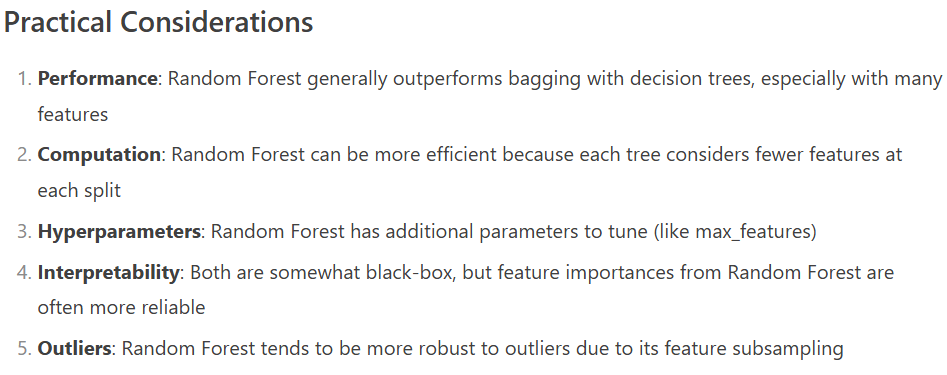

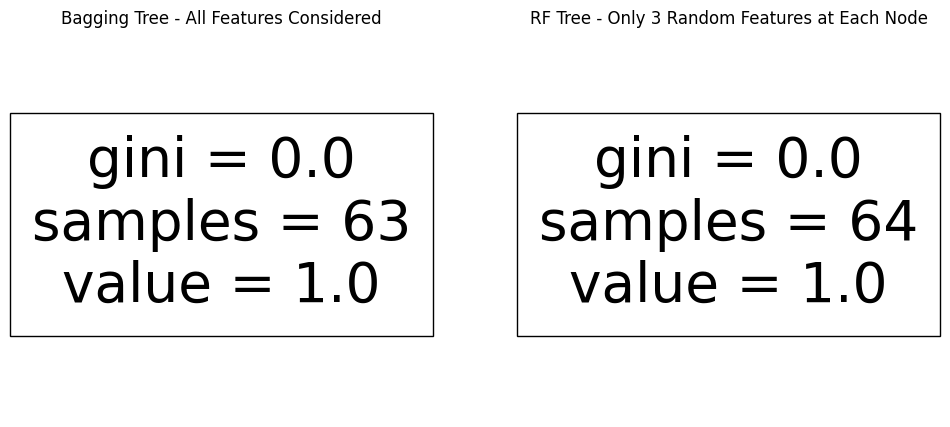

In [4]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Sample data
X = [[0,1,2,3,4,5,6,7,8,9] for _ in range(100)]  # 10 features
y = [0 if sum(x)<45 else 1 for x in X]  # Simple classification

# Bagging (only data randomness)
bag = BaggingClassifier(DecisionTreeClassifier(max_depth=2), n_estimators=3)
bag.fit(X, y)

# Random Forest (data + feature randomness)
rf = RandomForestClassifier(max_depth=2, n_estimators=3, max_features=3)
rf.fit(X, y)

# Plot first tree from each
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_tree(bag.estimators_[0], feature_names=[f"F{i}" for i in range(10)])
plt.title("Bagging Tree - All Features Considered")

plt.subplot(1,2,2)
plot_tree(rf.estimators_[0], feature_names=[f"F{i}" for i in range(10)])
plt.title("RF Tree - Only 3 Random Features at Each Node")
plt.show()

### **Bagging vs. Random Forest: Minimal Yet Powerful Comparison**  

#### **1. Randomness Application**  
- **Bagging**:  
  ✅ **Tree-level** – Random data sampling (bootstrap)  
  ❌ All features considered at every node  
- **Random Forest**:  
  ✅ **Tree-level** + **Node-level** – Random data **and** random feature subset per split  

#### **2. Diversity in Models**  
- **Bagging**:  
  🌳 Trees differ only due to different training data  
  🔄 Risk of similar trees if strong features dominate  
- **Random Forest**:  
  🌳🌳 Trees differ due to **data + feature randomness**  
  🔄 More decorrelated → Better ensemble robustness  

#### **3. Overfitting Resistance**  
- **Bagging**:  
  🛡️ Reduces variance via averaging  
  ⚠️ Can still overfit if trees are too deep  
- **Random Forest**:  
  🛡️🛡️ **Double protection** – Data & feature randomness  
  ⚠️ Harder to overfit (but possible with noisy data)  

#### **4. Performance**  
- **Bagging**:  
  ⚡ Good, but may plateau with correlated trees  
- **Random Forest**:  
  ⚡⚡ **Often better** – Handles high-dimensional & noisy data well  

#### **5. When to Use Which?**  
- **Use Bagging When**:  
  ✅ Few features, shallow trees, or non-tree base models  
  ✅ Interpretability matters slightly more  
- **Use Random Forest When**:  
  ✅ Many features, deep trees, or noisy data  
  ✅ Need better generalization & robustness  

**Final Takeaway**:  
🔹 **Bagging = Random data → Trees**  
🔹 **Random Forest = Random data + Random features → Trees**  
🔹 **RF usually wins, but bagging has niche uses!** 🏆